# Titanic Survival Prediction with Keras

## Projenin Amacı

Bu projenin amacı, Titanic yolcu verilerini kullanarak bir yolcunun hayatta kalıp kalmadığını tahmin eden bir sınıflandırma modeli geliştirmektir.

Bu çalışmada veri seti incelenecek, eksik değerler temizlenecek, kategorik veriler sayısal hale getirilecek ve TensorFlow/Keras kullanılarak deep learning tabanlı bir sınıflandırma modeli kurulacaktır.

## Yol Haritası

1. Titanic veri setini yükleme
2. Veri setini inceleme
3. Eksik verileri temizleme
4. Kategorik verileri sayısal hale getirme
5. Veriyi eğitim ve test olarak ayırma
6. Keras deep learning modeli kurma
7. Model başarısını değerlendirme
8. Sonuçları yorumlama


In [1]:
# Bu hücrede Titanic projesi için uygun bir kapak görselini notebook içinde gösteriyoruz.
# Görsel, projenin konusunu daha anlaşılır ve dikkat çekici hale getirir.

from IPython.display import Image, display

display(Image(url="https://upload.wikimedia.org/wikipedia/commons/f/fd/RMS_Titanic_3.jpg", width=800))


In [2]:
# Bu hücrede Kaggle'a eklenen Titanic veri setinin dosyalarını kontrol ediyoruz.
# Böylece train.csv ve test.csv dosyalarının yolunu öğreneceğiz.

import os

os.listdir("/kaggle/input")


['competitions']

In [3]:
# Bu hücrede Titanic yarışma dosyalarının bulunduğu klasörü buluyoruz.
# Böylece train.csv ve test.csv dosyalarına ulaşacağız.

os.listdir("/kaggle/input/competitions")


['titanic']

In [4]:
# Bu hücrede Titanic klasörünün içindeki dosyaları kontrol ediyoruz.
# train.csv eğitim dosyası, test.csv ise Kaggle tahmin dosyasıdır.

DATA_PATH = "/kaggle/input/competitions/titanic"
os.listdir(DATA_PATH)


['train.csv', 'test.csv', 'gender_submission.csv']

In [5]:
# Bu hücrede Titanic eğitim ve test veri setlerini okuyoruz.
# train.csv içinde Survived sütunu vardır; model bu sütunu öğrenmeye çalışacaktır.

import pandas as pd

train_df = pd.read_csv(DATA_PATH + "/train.csv")
test_df = pd.read_csv(DATA_PATH + "/test.csv")

train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Bu hücrede veri setinin boyutunu ve eksik değerlerini inceliyoruz.
# Böylece hangi sütunlarda temizlik yapılması gerektiğini göreceğiz.

print("Eğitim veri boyutu:", train_df.shape)
print("Test veri boyutu:", test_df.shape)

train_df.isnull().sum()


Eğitim veri boyutu: (891, 12)
Test veri boyutu: (418, 11)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Eksik Değerlerin İncelenmesi

Bu aşamada eğitim veri setinde hangi sütunlarda eksik değer bulunduğu kontrol edilecektir. Eksik değerler modelin doğru çalışmasını engelleyebileceği için temizleme işlemi yapılacaktır.

In [7]:
# Eksik değerleri kontrol ediyoruz

train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Eksik Verilerin Temizlenmesi

Bu aşamada çok fazla eksik değere sahip Cabin sütunu kaldırılacaktır. Age sütunu ortalama değer ile, Embarked sütunu ise en sık görülen değer ile doldurulacaktır.

In [8]:
# Eksik verileri temizliyoruz

train_df.drop("Cabin", axis=1, inplace=True)
test_df.drop("Cabin", axis=1, inplace=True)

train_df["Age"].fillna(train_df["Age"].mean(), inplace=True)
test_df["Age"].fillna(test_df["Age"].mean(), inplace=True)

train_df["Embarked"].fillna(train_df["Embarked"].mode()[0], inplace=True)

train_df.isnull().sum()

/tmp/ipykernel_16/2253619623.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["Age"].fillna(train_df["Age"].mean(), inplace=True)
/tmp/ipykernel_16/2253619623.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Kategorik Verilerin Sayısallaştırılması

Makine öğrenmesi modelleri metinsel verilerle çalışamaz. Bu nedenle Sex ve Embarked sütunları sayısal değerlere dönüştürülecektir.

In [9]:
# Kategorik verileri sayısala çeviriyoruz

train_df["Sex"] = train_df["Sex"].map({"male":0, "female":1})
test_df["Sex"] = test_df["Sex"].map({"male":0, "female":1})

train_df = pd.get_dummies(train_df, columns=["Embarked"], drop_first=True)
test_df = pd.get_dummies(test_df, columns=["Embarked"], drop_first=True)

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True


## Özellik Seçimi (Feature Selection)

Bu aşamada model için gereksiz olan sütunlar çıkarılacaktır.
Name, Ticket ve Cabin sütunları modele doğrudan katkı sağlamadığı için kaldırılacaktır.

In [10]:
# Gereksiz sütunları kaldırıyoruz

train_df = train_df.drop(["Name","Ticket"], axis=1)
test_df = test_df.drop(["Name","Ticket"], axis=1)

train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,False,True
1,2,1,1,1,38.0,1,0,71.2833,False,False
2,3,1,3,1,26.0,0,0,7.9250,False,True
3,4,1,1,1,35.0,1,0,53.1000,False,True
4,5,0,3,0,35.0,0,0,8.0500,False,True


## Eğitim ve Test Verisinin Hazırlanması

Bu aşamada modelin öğreneceği giriş verileri (X) ve hedef değişken (y) ayrılacaktır.
Daha sonra veri eğitim ve test olarak ikiye bölünecektir.

In [11]:
# X ve y değişkenlerini oluşturuyoruz

from sklearn.model_selection import train_test_split

X = train_df.drop("Survived", axis=1)
y = train_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(712, 9)
(179, 9)


## Keras Deep Learning Modelinin Kurulması

Bu aşamada TensorFlow/Keras kullanılarak yapay sinir ağı modeli oluşturulacaktır.
Model eğitim verisi üzerinde öğrenme gerçekleştirecek ve Titanic yolcularının hayatta kalma durumunu tahmin edecektir.

In [12]:
# Keras modeli oluşturuyoruz

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(9,)))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

2026-05-13 06:42:34.094781: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778654554.324450      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778654554.386607      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778654554.904914      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778654554.904958      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778654554.904961      16 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

## Modelin Eğitilmesi

Bu aşamada Keras modeli eğitim verisi üzerinde eğitilecektir. Model, yolcuların özelliklerinden hayatta kalıp kalmadıklarını öğrenmeye çalışacaktır.

In [13]:
# Modeli eğitiyoruz

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5864 - loss: 3.0976 - val_accuracy: 0.4804 - val_loss: 0.9904
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5842 - loss: 0.9220 - val_accuracy: 0.5698 - val_loss: 0.7405
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6527 - loss: 0.6849 - val_accuracy: 0.6704 - val_loss: 0.6346
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6393 - loss: 0.6646 - val_accuracy: 0.6648 - val_loss: 0.6016
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6648 - loss: 0.6030 - val_accuracy: 0.5978 - val_loss: 0.6590
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6397 - loss: 0.6635 - val_accuracy: 0.7095 - val_loss: 0.5780
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6690 - loss: 0.6376 - val_accuracy: 0.6536 - val_loss: 0.6319
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6834 - loss: 0.5831 - val_accuracy: 0.6760 - val_loss:

## Model Performansının Görselleştirilmesi

Bu bölümde eğitim sürecindeki accuracy ve loss değerleri grafik halinde incelenecektir.
Böylece modelin öğrenme performansı yorumlanabilecektir.

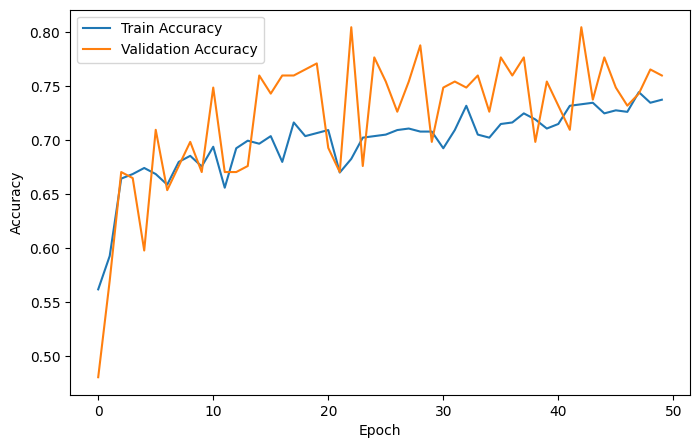

In [14]:
# Accuracy grafiği çiziyoruz

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

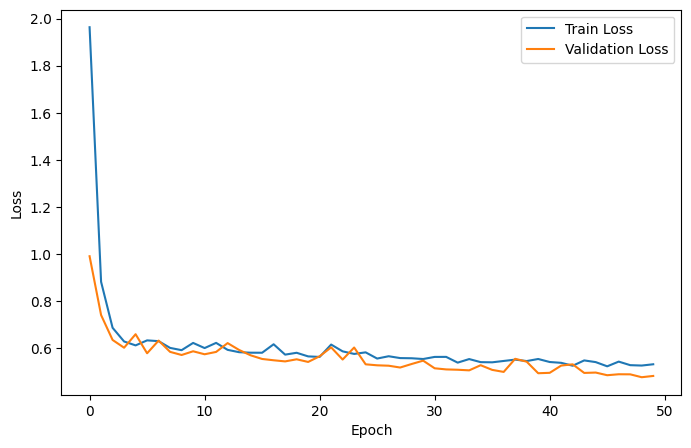

In [15]:
# Loss grafiği çiziyoruz

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Sonuç ve Değerlendirme

Bu projede Titanic yolcu verileri kullanılarak TensorFlow/Keras tabanlı bir derin öğrenme modeli geliştirilmiştir.

Proje kapsamında:

- Veri seti incelenmiştir
- Eksik değerler temizlenmiştir
- Kategorik veriler sayısal hale getirilmiştir
- Eğitim ve test veri setleri oluşturulmuştur
- Yapay sinir ağı modeli kurulmuştur
- Model performansı grafiklerle analiz edilmiştir

Model yaklaşık %80 civarında doğruluk (accuracy) başarısı elde etmiştir. Bu sonuç, yapay sinir ağlarının sınıflandırma problemlerinde etkili sonuçlar verebildiğini göstermektedir.

Accuracy ve loss grafiklerine bakıldığında modelin öğrenme sürecinin genel olarak dengeli ilerlediği görülmektedir.